# 01 - Data Exploration: Understanding Karachi's Weather

**Goal:** Before building any model, we must understand our data. This notebook
answers the questions:

- What does the dataset look like? (shape, columns, types)
- Is the data complete? (missing values, duplicates)
- What are typical weather values? (summary statistics)
- How often does it rain in Karachi? (class distribution)
- What relationships exist between weather variables? (visualizations)

No model is trained here. This is pure exploration.


## Setup

We import the libraries we need and point to the downloaded dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Figures will be saved next to the repo's reports/figures folder,
# whether the notebook is run from the project root or from notebooks/
from pathlib import Path
FIG_DIR = Path("reports") / "figures"
if not FIG_DIR.exists():
    FIG_DIR = Path("..") / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path("data/raw/karachi_weather.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("..") / "data/raw/karachi_weather.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
print("Dataset loaded:", df.shape)

Dataset loaded: (15198, 12)


## 1. Shape, columns and data types

`df.shape` tells us how many rows (days) and columns (variables) we have.
`df.dtypes` tells us each column's data type - important because model
training requires numeric data.


In [2]:
print("Rows (days):", df.shape[0])
print("Columns (variables):", df.shape[1])
print()
print(df.dtypes)

Rows (days): 15198
Columns (variables): 12

Date               datetime64[us]
MaxTemperature            float64
MinTemperature            float64
MeanTemperature           float64
Precipitation             float64
Rainfall                  float64
Pressure                  float64
Humidity                    int64
CloudCoverage               int64
WindSpeed                 float64
WindDirection               int64
WeatherCode                 int64
dtype: object


## 2. Missing values

Missing values must be detected early. Real weather data is often incomplete.
If a column has many missing values we must decide how to handle it in the
cleaning phase.


In [3]:
missing = df.isna().sum()
missing_df = pd.DataFrame({"Missing": missing, "Percent": (missing / len(df) * 100).round(2)})
print(missing_df[missing_df["Missing"] > 0])
print()
print("Total missing cells:", df.isna().sum().sum())

Empty DataFrame
Columns: [Missing, Percent]
Index: []

Total missing cells: 0


## 3. Duplicate rows

Duplicate rows would let the same day count twice, which could bias the model.
We check for exact duplicate rows.


In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 4. Summary statistics

`describe()` gives count, mean, standard deviation, min, quartiles and max for
each numeric column. This tells us the *typical* weather range in Karachi.


In [5]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
Date,15198,2005-10-21 12:00:00,1985-01-01 00:00:00,1995-05-28 06:00:00,2005-10-21 12:00:00,2016-03-16 18:00:00,2026-08-11 00:00:00,NaN
MaxTemperature,15198.0,30.348967,16.1,28.3,30.8,32.7,44.8,3.567049
MinTemperature,15198.0,22.473812,7.7,18.5,24.0,26.6,32.6,4.927396
MeanTemperature,15198.0,26.066805,12.1,23.2,27.3,29.0,37.6,3.85326
Precipitation,15198.0,0.447105,0.0,0.0,0.0,0.0,304.9,4.390296
Rainfall,15198.0,0.447105,0.0,0.0,0.0,0.0,304.9,4.390296
Pressure,15198.0,1008.374648,990.9,1002.7,1008.8,1014.1,1023.7,6.706471
Humidity,15198.0,66.591986,14.0,57.0,72.0,77.0,92.0,14.855862
CloudCoverage,15198.0,29.876497,0.0,2.0,22.0,50.0,100.0,29.559359
WindSpeed,15198.0,23.036202,7.7,18.1,22.6,27.5,50.5,6.721332


## 5. Date range

How much history do we have? When does it start and end?


In [6]:
print("Earliest date:", df["Date"].min().date())
print("Latest date:  ", df["Date"].max().date())
print("Years covered:", df["Date"].dt.year.nunique())
print("Days of data: ", len(df))

Earliest date: 1985-01-01
Latest date:   2026-08-11
Years covered: 42
Days of data:  15198


## 6. Rain / No-Rain distribution

We define a "rainy day" as one where `Rainfall > 0 mm`. This threshold is
documented and used consistently through the whole project.

This is our future target concept: **RainTomorrow** = whether *tomorrow* is a
rainy day. For now we just look at today's rain frequency.


Rain days:    2023 (13.3%)
No-rain days: 13175 (86.7%)


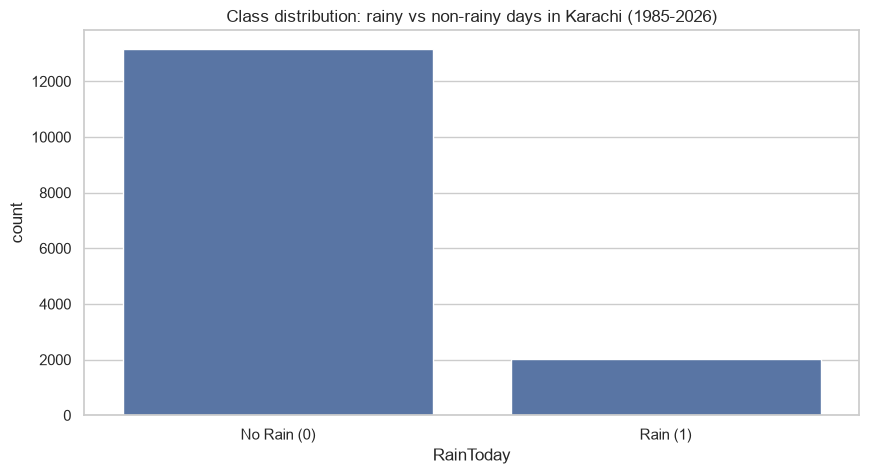

In [7]:
df["RainToday"] = (df["Rainfall"] > 0).astype(int)

rain_counts = df["RainToday"].value_counts().sort_index()
print("Rain days:   ", rain_counts.get(1, 0), f"({rain_counts.get(1, 0) / len(df) * 100:.1f}%)")
print("No-rain days:", rain_counts.get(0, 0), f"({rain_counts.get(0, 0) / len(df) * 100:.1f}%)")

fig, ax = plt.subplots()
sns.countplot(x="RainToday", data=df, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Rain (0)", "Rain (1)"])
ax.set_title("Class distribution: rainy vs non-rainy days in Karachi (1985-2026)")
plt.savefig(FIG_DIR / "01_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

### What this tells us

Only **~13%** of days have any rain. This is a **class imbalance** - a model
could get 87% accuracy just by always predicting "no rain". This is why later
we will pay special attention to recall for rainy days, and why accuracy alone
is a misleading metric.


## 7. Rainfall over time

Plotting rainfall over the years shows the seasonal rhythm of Karachi weather
- including the monsoon peaks in summer.


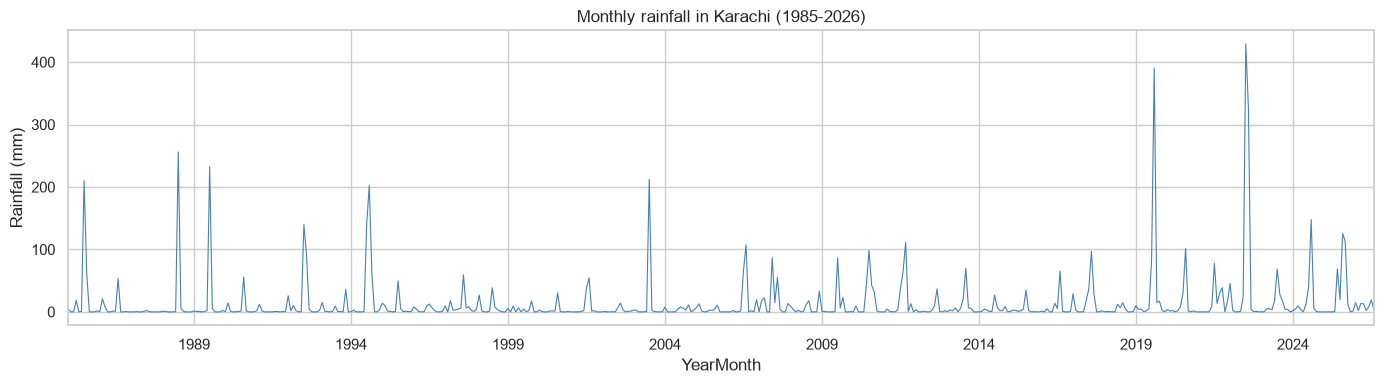

In [8]:
# Monthly total rainfall -> smoother view of seasonality
df["YearMonth"] = df["Date"].dt.to_period("M")
monthly_rain = df.groupby("YearMonth")["Rainfall"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
monthly_rain.plot(ax=ax, color="steelblue", linewidth=0.8)
ax.set_title("Monthly rainfall in Karachi (1985-2026)")
ax.set_ylabel("Rainfall (mm)")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_rainfall_over_time.png", dpi=120, bbox_inches="tight")
plt.show()

### What this tells us

Rainfall is highly seasonal: long dry periods with sharp monsoon peaks in
summer (June-August). Because patterns repeat by season, features like
**Month** will likely be very informative for the model.


## 8. Temperature distribution

Karachi has a hot desert/coastal climate. Let's see the typical range.


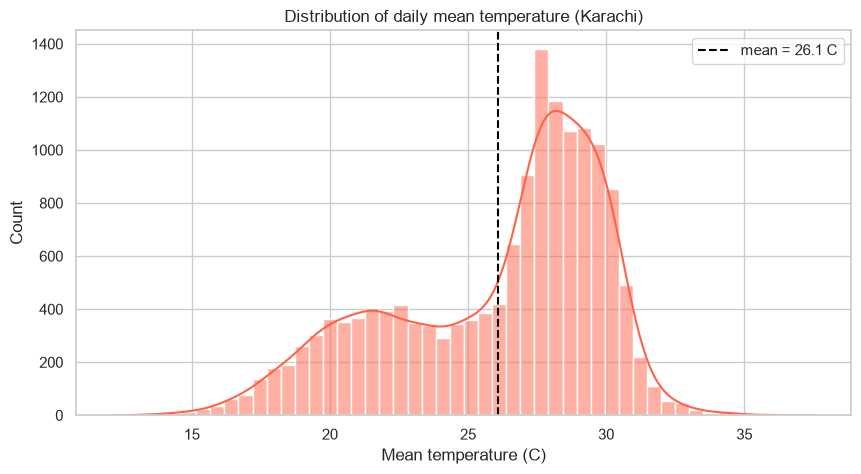

In [9]:
fig, ax = plt.subplots()
sns.histplot(df["MeanTemperature"], bins=50, kde=True, color="tomato", ax=ax)
ax.axvline(df["MeanTemperature"].mean(), color="black", linestyle="--", label=f"mean = {df['MeanTemperature'].mean():.1f} C")
ax.set_title("Distribution of daily mean temperature (Karachi)")
ax.set_xlabel("Mean temperature (C)")
ax.legend()
plt.savefig(FIG_DIR / "01_temperature_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

### What this tells us

Temperatures are roughly **18-34C** with a peak around 28C - warm all year, as
expected for Karachi. There is no freezing weather, so snow/ice are irrelevant.


## 9. Humidity distribution

Humidity is one of the strongest predictors of rain, so we study it closely.


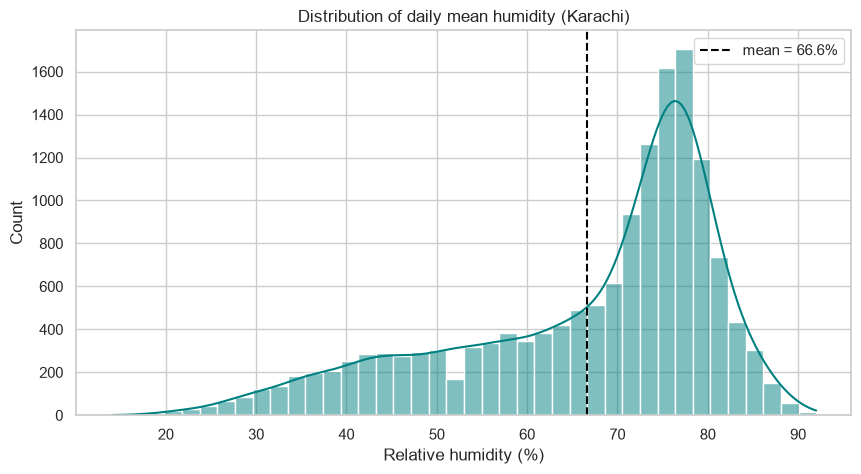

In [10]:
fig, ax = plt.subplots()
sns.histplot(df["Humidity"], bins=40, kde=True, color="teal", ax=ax)
ax.axvline(df["Humidity"].mean(), color="black", linestyle="--", label=f"mean = {df['Humidity'].mean():.1f}%")
ax.set_title("Distribution of daily mean humidity (Karachi)")
ax.set_xlabel("Relative humidity (%)")
ax.legend()
plt.savefig(FIG_DIR / "01_humidity_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

### What this tells us

Humidity spans roughly **30-90%** with a strong mode near the high end -
Karachi is humid most of the year (coastal). High humidity is a precondition
for rain.


## 10. Rain vs Humidity

Boxplots let us compare the humidity distribution on rainy vs non-rainy days.
If rainy days have clearly higher humidity, that feature is informative.


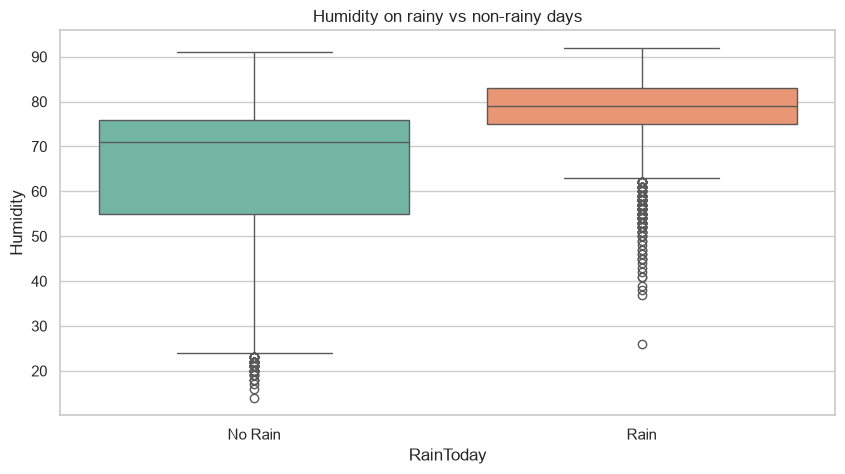

In [11]:
fig, ax = plt.subplots()
sns.boxplot(x="RainToday", y="Humidity", data=df, hue="RainToday", legend=False, palette="Set2", ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Rain", "Rain"])
ax.set_title("Humidity on rainy vs non-rainy days")
plt.savefig(FIG_DIR / "01_rain_vs_humidity.png", dpi=120, bbox_inches="tight")
plt.show()

### What this tells us

Rainy days tend to have **higher humidity** (higher median and higher minimum).
This is expected and confirms humidity is a meaningful predictor.


## 11. Rain vs Temperature

Same comparison for temperature.


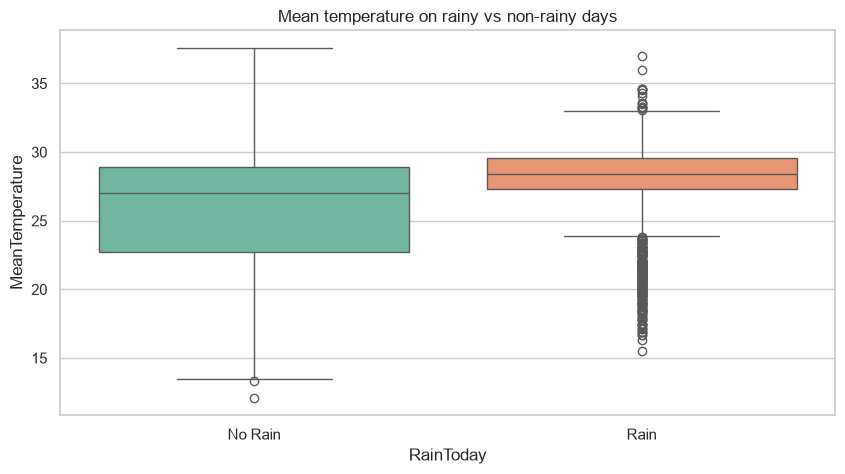

In [12]:
fig, ax = plt.subplots()
sns.boxplot(x="RainToday", y="MeanTemperature", data=df, hue="RainToday", legend=False, palette="Set2", ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Rain", "Rain"])
ax.set_title("Mean temperature on rainy vs non-rainy days")
plt.savefig(FIG_DIR / "01_rain_vs_temperature.png", dpi=120, bbox_inches="tight")
plt.show()

### What this tells us

Rain happens more in the hot season (monsoon) - rainy days have higher
temperature, but with a wide overlap. Temperature alone is weak but combined
with other features it helps.


## 12. Monthly rain pattern (seasonality)

Averaging rainfall by month reveals Karachi's wet and dry seasons clearly.
This motivates creating a **Month** feature.


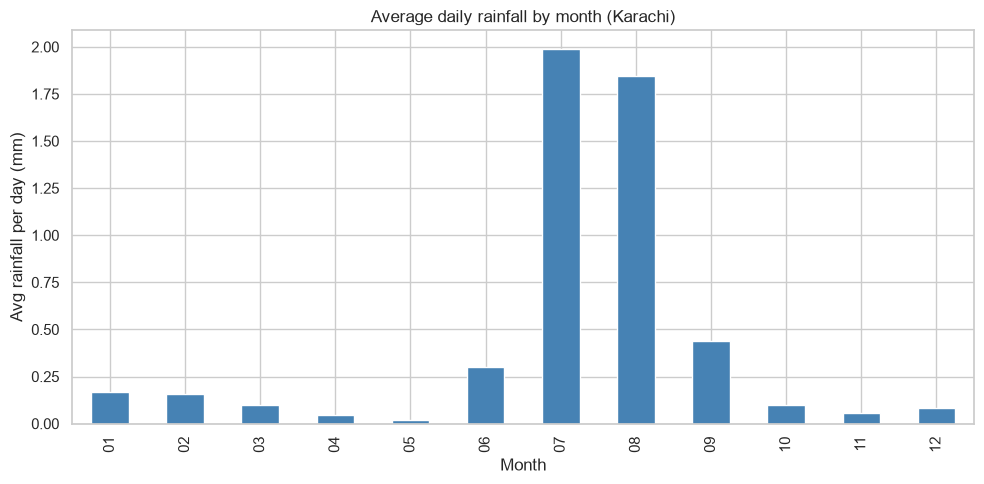

In [13]:
avg_monthly = df.groupby(df["Date"].dt.month)["Rainfall"].mean()

fig, ax = plt.subplots()
avg_monthly.plot(kind="bar", color="steelblue", ax=ax)
ax.set_title("Average daily rainfall by month (Karachi)")
ax.set_xlabel("Month")
ax.set_ylabel("Avg rainfall per day (mm)")
ax.set_xticklabels([f"{m:02d}" for m in range(1, 13)])
plt.tight_layout()
plt.savefig(FIG_DIR / "01_monthly_rain_pattern.png", dpi=120, bbox_inches="tight")
plt.show()

### What this tells us

Rain concentrates in **July and August** (monsoon), with a smaller secondary
peak. Months like November to May are almost dry. Seasonality is very strong,
so the **Month** feature should be powerful.


## 13. Correlation heatmap

Correlation measures how two numeric variables move together (from -1 to +1).
It can reveal redundant features and early hints about what predicts rain.


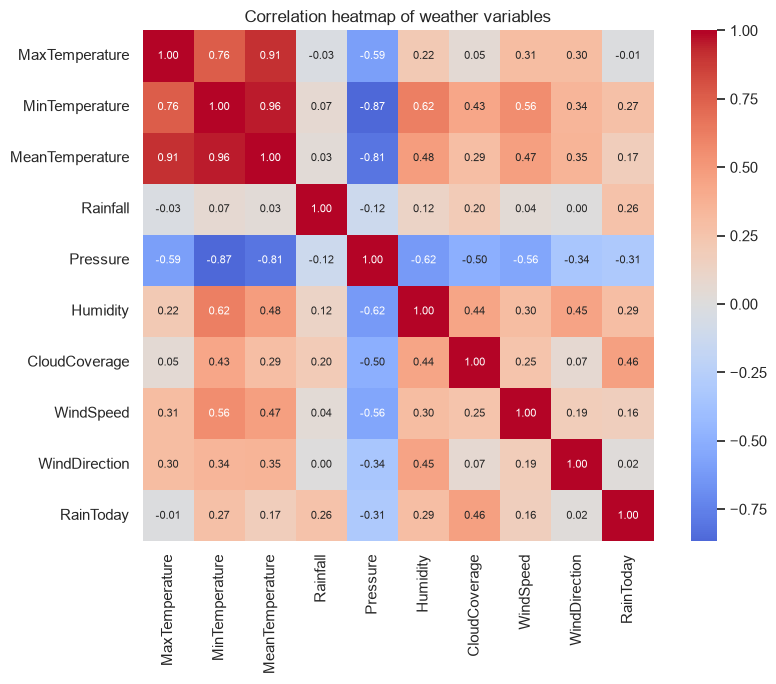

In [14]:
# WeatherCode is a categorical code, so we exclude it from correlation
corr_cols = ["MaxTemperature", "MinTemperature", "MeanTemperature",
             "Rainfall", "Pressure", "Humidity", "CloudCoverage",
             "WindSpeed", "WindDirection", "RainToday"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation heatmap of weather variables")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

### What this tells us

- **RainToday vs CloudCoverage** and **RainToday vs Humidity** show the
  strongest (though moderate) correlations with rain.
- **Pressure** is slightly negatively correlated with rain (rain often comes
  with lower pressure).
- Temperature columns are highly correlated with *each other* - the model
  should be fine with this, but we may not need all three.


## Summary of what we learned

| Finding | Implication |
|---------|-------------|
| 15,198 daily rows, 1985-2026, no missing values, no duplicates | Clean start; cleaning phase should be light |
| ~13% of days are rainy | Class imbalance; accuracy alone is misleading |
| Rain is highly seasonal (Jul-Aug monsoon) | Create a Month feature |
| Humidity, cloud cover, pressure correlate most with rain | Likely to be the most important features |
| Temperature is warm all year, no snow | No need for snow-related features |

**Next step:** Phase 2 - Data Cleaning. With this dataset the cleaning needs
are minimal, but we will still inspect carefully before building any model.
